<a href="https://colab.research.google.com/github/MEdan-US/Mini-Project/blob/hoang066/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Prelimaniries

## Import and Configuration

Sử dụng thư viện nào thì điền ở đây, không ghi dưới code

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_theme(style='whitegrid')
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
# Mute warnings
warnings.filterwarnings('ignore')
print('Import Library Successfully')

Import Library Successfully


## Prepare dataset

In [3]:
!gdown 1T0VaZxJHvzLhh0IrhheBjVrJSxvBG9Rh

Downloading...
From: https://drive.google.com/uc?id=1T0VaZxJHvzLhh0IrhheBjVrJSxvBG9Rh
To: /content/ai_student_impact_dataset.csv
100% 5.89M/5.89M [00:00<00:00, 25.9MB/s]


In [4]:
DATA_PATH="/content/ai_student_impact_dataset.csv"
df=pd.read_csv(DATA_PATH,index_col="Student_ID")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  object 
 1   Year_of_Study               50000 non-null  object 
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  object 
 5   Prompt_Engineering_Skill    50000 non-null  object 
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  object 
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_GPA           50000 non-null  float64
 13  Skill_Retention_Score       50

Biến Target là `Post_Semester GPA`

# Step 1: Exploratory Data Analysis

## Numerical Features (Mon)

Yêu cầu:
- Cấu trúc dữ liệu:
  - Xác định kiểu dữ liệu cụ thể (int64, float64).
  - Kiểm tra tỷ lệ dữ liệu bị khuyết (Missing values) trên từng biến định lượng và đề xuất hướng xử lý (điền bằng mean, median hay xóa).
- Thống kê mô tả (Descriptive Statistics):
  - Tính toán các chỉ số cơ bản: Trung bình (Mean), Trung vị (Median), Độ lệch chuẩn (Std), Giá trị lớn nhất/nhỏ nhất (Min/Max), và các khoảng tứ phân vị (25%, 50%, 75%).
  - Vẽ biểu đồ phân phối (Histogram, KDE Plot) để xem dữ liệu có bị lệch (Skewed) hay tuân theo phân phối chuẩn không.
  - Phát hiện dữ liệu dị biệt (Outliers) bằng biểu đồ Boxplot hoặc phương pháp IQR / Z-score.
- Phân tích mức độ tương quan :
  - Vẽ ma trận tương quan (Correlation Matrix / Heatmap) giữa các biến định lượng với nhau để tìm ra hiện tượng đa cộng tuyến (Multicollinearity).
  - Vẽ Scatter Plot giữa các biến định lượng quan trọng để thấy xu hướng tuyến tính hoặc phi tuyến.

In [5]:
numerical_data=df.select_dtypes(include=['int64', 'float64'])
numerical_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pre_Semester_GPA            50000 non-null  float64
 1   Weekly_GenAI_Hours          50000 non-null  float64
 2   Tool_Diversity              50000 non-null  int64  
 3   Traditional_Study_Hours     50000 non-null  float64
 4   Perceived_AI_Dependency     50000 non-null  int64  
 5   Anxiety_Level_During_Exams  50000 non-null  int64  
 6   Post_Semester_GPA           50000 non-null  float64
 7   Skill_Retention_Score       50000 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 3.4 MB


## Categorical Features (Thanh Hoàng)

Yêu cầu:
- Cấu trúc dữ liệu:
  - Xác định kiểu dữ liệu (object, category, bool).
  - Kiểm tra số lượng giá trị duy nhất (Cardinality - nunique). Lưu ý đặc biệt: Nếu một biến định tính có quá nhiều nhóm (ví dụ >50 nhóm), cần cảnh báo vì sẽ khó mã hóa sau này.

  - Kiểm tra tỷ lệ dữ liệu bị khuyết (Missing values) và đề xuất hướng xử lý (điền bằng nhóm xuất hiện nhiều nhất - Mode, hoặc tạo một nhóm mới tên là "Unknown").

- Thống kê mô tả & Tần suất:
  - Lập bảng tần suất (Count) và tần suất phần trăm (Percentage) cho từng danh mục.
  - Trực quan hóa bằng biểu đồ cột (Bar chart) hoặc biểu đồ tròn (Pie chart - chỉ dùng khi có ít hơn 5 danh mục) để xem có sự mất cân bằng giữa các nhóm hay không.

- Mối tương quan:
  - Sử dụng Crosstab để xem tần suất kết hợp giữa các biến định tính quan trọng với nhau.

In [6]:
categorical_data=df.select_dtypes(include=['object','bool'])
categorical_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 100001 to 150000
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Major_Category            50000 non-null  object
 1   Year_of_Study             50000 non-null  object
 2   Primary_Use_Case          50000 non-null  object
 3   Prompt_Engineering_Skill  50000 non-null  object
 4   Paid_Subscription         50000 non-null  bool  
 5   Institutional_Policy      50000 non-null  object
 6   Burnout_Risk_Level        50000 non-null  object
dtypes: bool(1), object(6)
memory usage: 2.7+ MB


In [7]:
categorical_data.nunique()

,0
Major_Category,5
Year_of_Study,5
Primary_Use_Case,5
Prompt_Engineering_Skill,3
Paid_Subscription,2
Institutional_Policy,3
Burnout_Risk_Level,3


In [84]:
categorical_data.isnull().sum()

,0
Major_Category,0
Year_of_Study,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Paid_Subscription,0
Institutional_Policy,0
Burnout_Risk_Level,0


### Cấu trúc dữ liệu & Kiểm tra đặc trưng

Qua phân tích tập dữ liệu `ai_student_impact_dataset.csv`, nhóm ghi nhận có tổng cộng 7 biến phân loại phản ánh hành vi, môi trường và tác động của AI đối với sinh viên.

| Biến định tính | Mô tả ý nghĩa | Kiểu dữ liệu | Số nhóm (Cardinality) | Missing |
| :--- | :--- | :---: | :---: | :---: |
| **Major_Category** | Khối ngành học thuật | object | 5 | 0 |
| **Year_of_Study** | Năm học của sinh viên | object | 5 | 0 |
| **Primary_Use_Case** | Mục đích sử dụng AI chính | object | 5 | 0 |
| **Prompt_Engineering_Skill** | Kỹ năng viết Prompt | object | 3 | 0 |
| **Paid_Subscription** | Có trả phí mua AI không | bool | 2 | 0 |
| **Institutional_Policy** | Quy định AI của nhà trường | object | 3 | 0 |
| **Burnout_Risk_Level** | Mức rủi ro kiệt sức tâm lý | object | 3 | 0 |

**Nhận xét:**
* **Chất lượng dữ liệu lý tưởng:** Tỷ lệ khuyết trên toàn bộ 7 biến đều là **0%**. Dữ liệu được thu thập rất sạch, không yêu cầu các kỹ thuật nội suy hay loại bỏ dòng khuyết thiếu (imputation/dropping).
* **Cardinality hoàn hảo:** Tất cả các biến đều có số nhóm <= 5. Cấu trúc này đảm bảo khi áp dụng kỹ thuật *One-Hot Encoding* ở bước chuẩn bị dữ liệu, số chiều của không gian ma trận mới sinh ra sẽ rất thấp (chỉ khoảng 26 cột bổ sung), tuyệt đối không gây ra hiện tượng bùng nổ số chiều (Curse of Dimensionality) làm ảnh hưởng tới thuật toán Machine Learning.

In [37]:
cat_cols = categorical_data.columns.tolist()


 ==== Bảng tần suất của Major_Category ====
                Count  Percentage (%)
Major_Category                       
STEM            15059           30.12
Business        12538           25.08
Humanities       9994           19.99
Medical          6476           12.95
Arts             5933           11.87


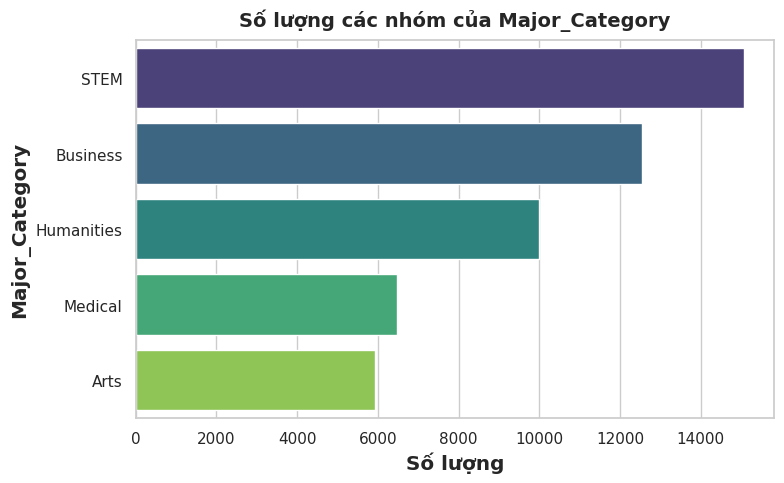


 ==== Bảng tần suất của Year_of_Study ====
               Count  Percentage (%)
Year_of_Study                       
Junior         11045           22.09
Freshman       11031           22.06
Senior         10634           21.27
Sophomore       9860           19.72
Graduate        7430           14.86


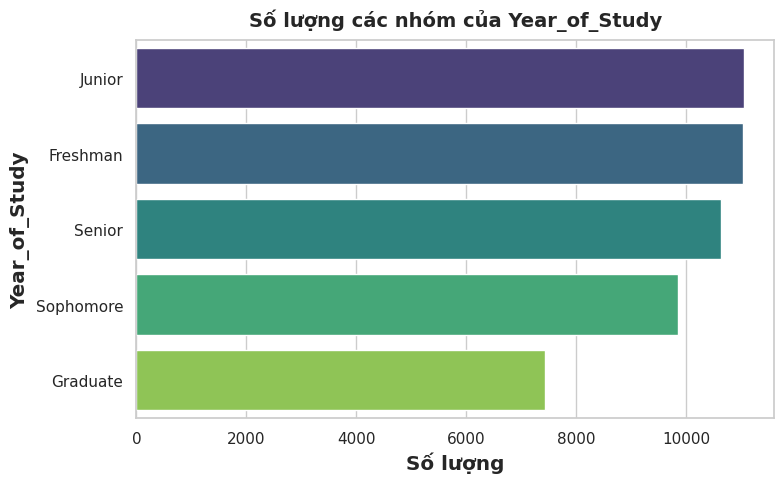


 ==== Bảng tần suất của Primary_Use_Case ====
                           Count  Percentage (%)
Primary_Use_Case                                
Debugging/Troubleshooting  12295           24.59
Copywriting/Drafting       12011           24.02
Ideation                   10721           21.44
Summarizing_Reading         8633           17.27
Direct_Answer_Generation    6340           12.68


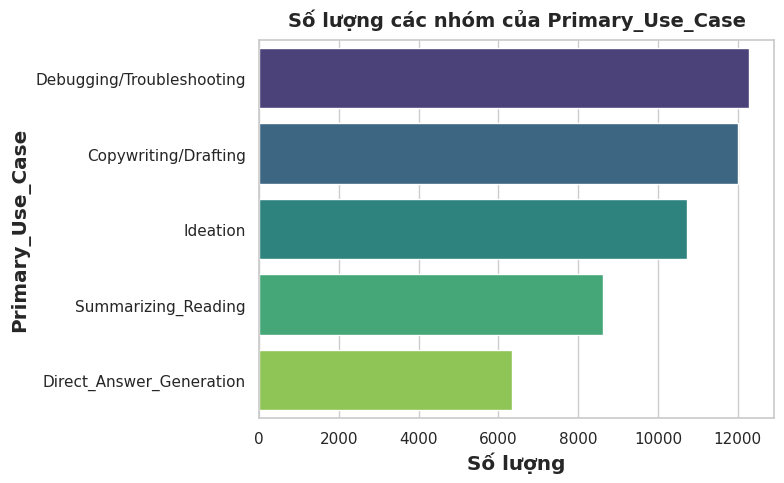


 ==== Bảng tần suất của Prompt_Engineering_Skill ====
                          Count  Percentage (%)
Prompt_Engineering_Skill                       
Beginner                  18495           36.99
Intermediate              17696           35.39
Advanced                  13809           27.62


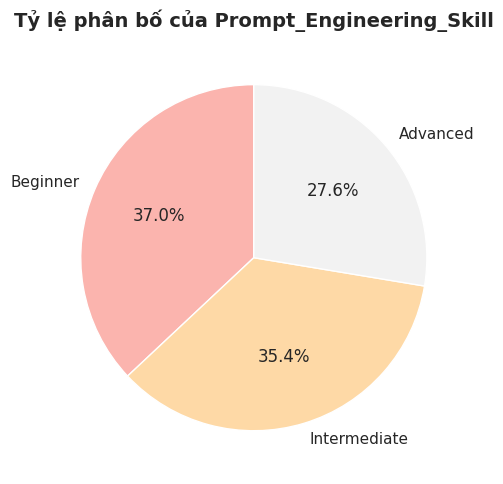


 ==== Bảng tần suất của Paid_Subscription ====
                   Count  Percentage (%)
Paid_Subscription                       
False              28846           57.69
True               21154           42.31


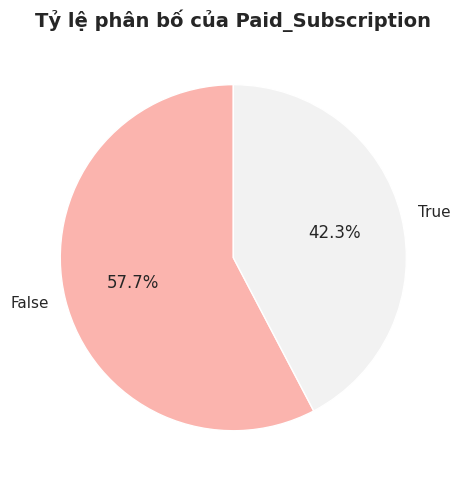


 ==== Bảng tần suất của Institutional_Policy ====
                       Count  Percentage (%)
Institutional_Policy                        
Allowed_With_Citation  25224           50.45
Actively_Encouraged    14988           29.98
Strict_Ban              9788           19.58


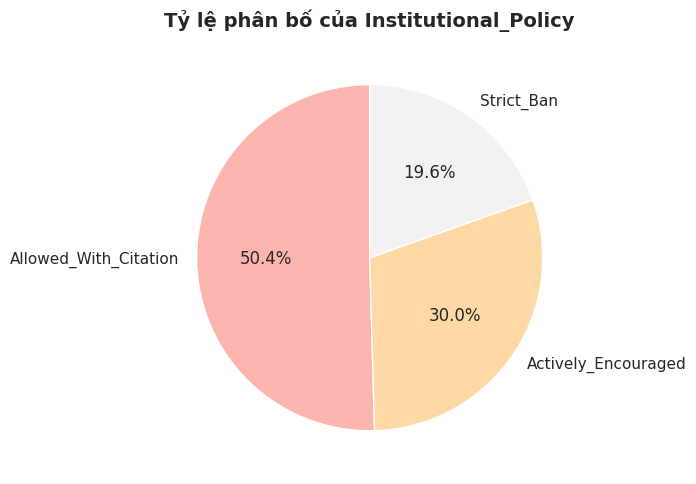


 ==== Bảng tần suất của Burnout_Risk_Level ====
                    Count  Percentage (%)
Burnout_Risk_Level                       
Medium              21144           42.29
Low                 16369           32.74
High                12487           24.97


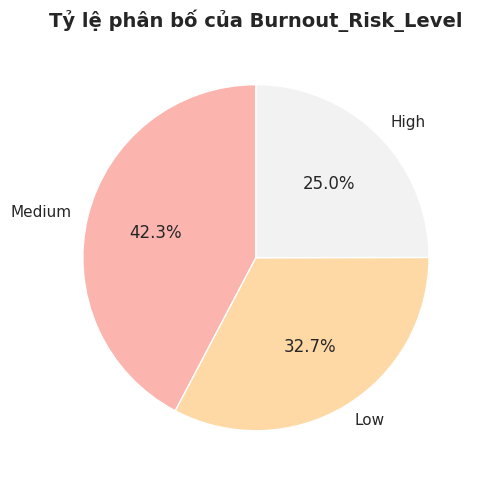

In [44]:
for col in cat_cols :
    print(f"\n ==== Bảng tần suất của {col} ====")
    freq_table = pd.DataFrame({
        'Count': categorical_data[col].value_counts(dropna=False),
        'Percentage (%)': (categorical_data[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    })
    print(freq_table)

    plt.figure(figsize=(8, 5))

    if categorical_data[col].nunique() < 5:
        categorical_data[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1', ylabel='')
        plt.title(f"Tỷ lệ phân bố của {col}")
    elif categorical_data[col].nunique() >= 5:
        sns.countplot(y=col, data=categorical_data, order=categorical_data[col].value_counts().index, palette='viridis')
        plt.title(f"Số lượng các nhóm của {col}")
        plt.xlabel("Số lượng")
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()

============ CROSSTAB 1: NGÀNH HỌC & MỨC ĐỘ KIỆT SỨC ============

 Bảng tần suất số lượng sinh viên:
Burnout_Risk_Level   Low  Medium  High
Major_Category                        
Arts                2014    2573  1346
Business            4193    5294  3051
Humanities          3606    4315  2073
Medical             2243    2733  1500
STEM                4313    6229  4517


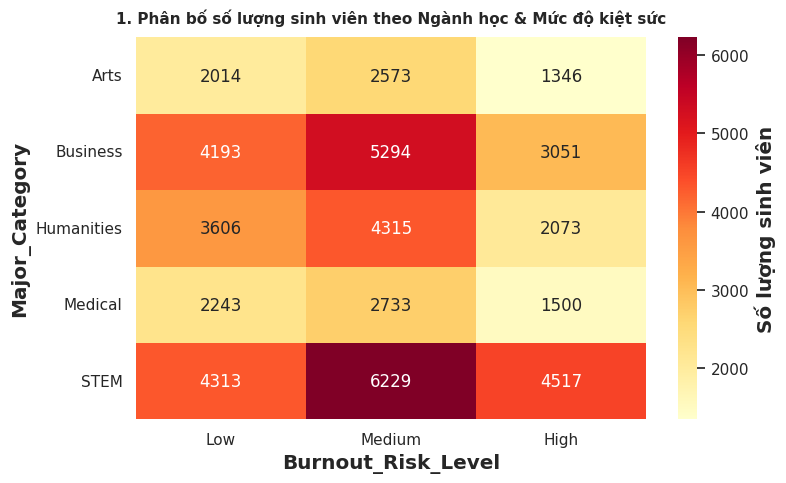

In [85]:
print("============ CROSSTAB 1: NGÀNH HỌC & MỨC ĐỘ KIỆT SỨC ============")
count_major_by_burnout = pd.crosstab(
    index=df['Major_Category'],
    columns=df['Burnout_Risk_Level']
)[['Low', 'Medium', 'High']]

print("\n Bảng tần suất số lượng sinh viên:")
print(count_major_by_burnout)

plt.figure(figsize=(8, 5))
sns.heatmap(count_major_by_burnout, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Số lượng sinh viên'})
plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.title('1. Phân bố số lượng sinh viên theo Ngành học & Mức độ kiệt sức', fontsize=11, fontweight='bold')
plt.ylabel('Major_Category')
plt.xlabel('Burnout_Risk_Level')
plt.tight_layout()
plt.show()

**💡 Insight:** STEM có tỷ lệ Burnout High cao nhất (30%), trong khi Arts có tỷ lệ Burnout Low cao nhất (33.9%). Ngành học ảnh hưởng đến stress của sinh viên.

============ CROSSTAB 2: KỸ NĂNG PROMPT & MỤC ĐÍCH SỬ DỤNG AI ============

 Bảng tần suất số lượng sinh viên:
Prompt_Engineering_Skill   Beginner  Intermediate  Advanced
Primary_Use_Case                                           
Copywriting/Drafting           4658          4214      3139
Debugging/Troubleshooting      4128          4391      3776
Direct_Answer_Generation       2376          2213      1751
Ideation                       4121          3793      2807
Summarizing_Reading            3212          3085      2336


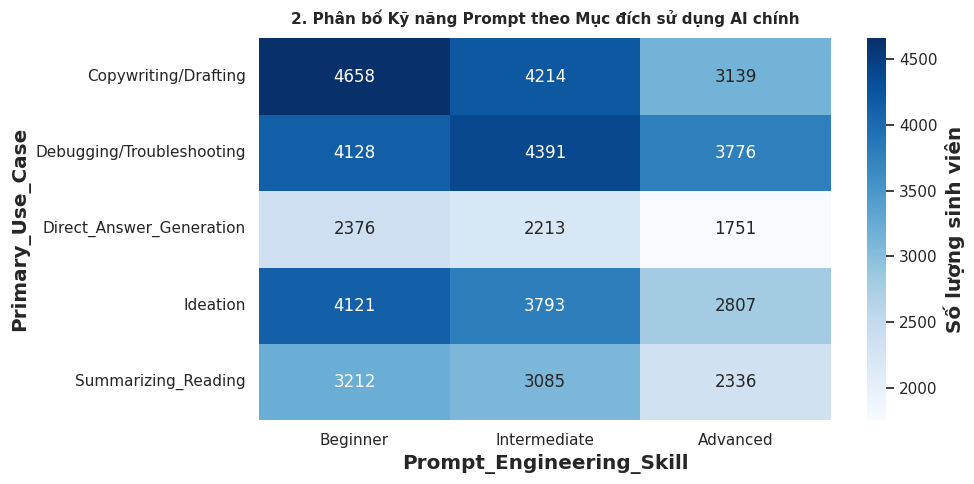

In [76]:
print("============ CROSSTAB 2: KỸ NĂNG PROMPT & MỤC ĐÍCH SỬ DỤNG AI ============")
count_skill_by_usecase = pd.crosstab(
    index=df['Primary_Use_Case'],
    columns=df['Prompt_Engineering_Skill']
)[['Beginner', 'Intermediate', 'Advanced']]

print("\n Bảng tần suất số lượng sinh viên:")
print(count_skill_by_usecase)

plt.figure(figsize=(10, 5))
sns.heatmap(count_skill_by_usecase, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Số lượng sinh viên'})
plt.yticks(rotation=0)
plt.title('2. Phân bố Kỹ năng Prompt theo Mục đích sử dụng AI chính', fontsize=11, fontweight='bold')
plt.ylabel('Primary_Use_Case')
plt.xlabel('Prompt_Engineering_Skill')
plt.tight_layout()
plt.show()

**💡 Insight:** Skill Level quyết định Mục Đích: Sinh viên skill khác nhau dùng AI cho mục đích khác nhau. Advanced = chuyên (Debugging), Beginner = generalist (dùng tất cả).

============ CROSSTAB 3: TRẢ PHÍ AI & MỨC ĐỘ KIỆT SỨC ============

 Bảng tần suất số lượng sinh viên:
Burnout_Risk_Level    Low  Medium  High
Paid_Subscription                      
False               10266   12491  6089
True                 6103    8653  6398


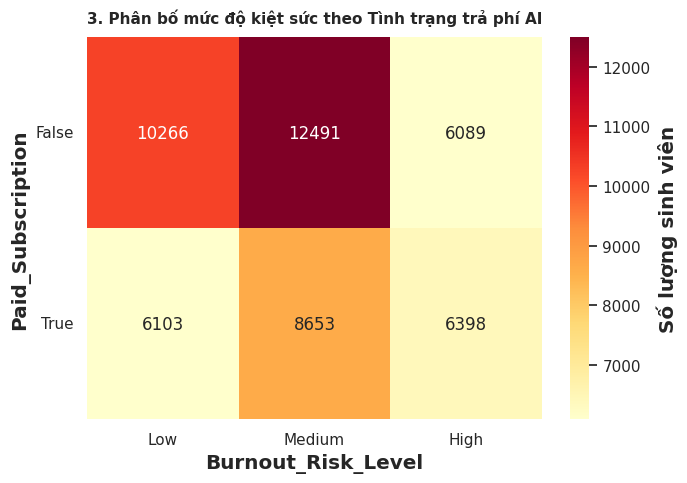

In [78]:
print("============ CROSSTAB 3: TRẢ PHÍ AI & MỨC ĐỘ KIỆT SỨC ============")
count_paid_by_burnout = pd.crosstab(
    index=df['Paid_Subscription'],
    columns=df['Burnout_Risk_Level']
)[['Low', 'Medium', 'High']]

print("\n Bảng tần suất số lượng sinh viên:")
print(count_paid_by_burnout)

plt.figure(figsize=(7, 5))
sns.heatmap(count_paid_by_burnout, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Số lượng sinh viên'})

plt.yticks(rotation=0)
plt.xticks(rotation=0)

plt.title('3. Phân bố mức độ kiệt sức theo Tình trạng trả phí AI', fontsize=11, fontweight='bold')
plt.ylabel('Paid_Subscription')
plt.xlabel('Burnout_Risk_Level')
plt.tight_layout()
plt.show()

**💡 Insight:** Sinh viên có **Paid_Subscription = Yes** có tỷ lệ Burnout High cao hơn (30.2% vs 21.1%). Điều này gợi ý sinh viên stress hơn có thể sẵn sàng chi tiền cho AI tools để "cứu" họ khỏi workload quá tải.

============ CROSSTAB 4: QUY ĐỊNH TRƯỜNG & MỨC ĐỘ KIỆT SỨC ============

 Bảng tần suất số lượng sinh viên:
Burnout_Risk_Level      Low  Medium  High
Institutional_Policy                     
Actively_Encouraged    5079    6346  3563
Allowed_With_Citation  8320   10893  6011
Strict_Ban             2970    3905  2913


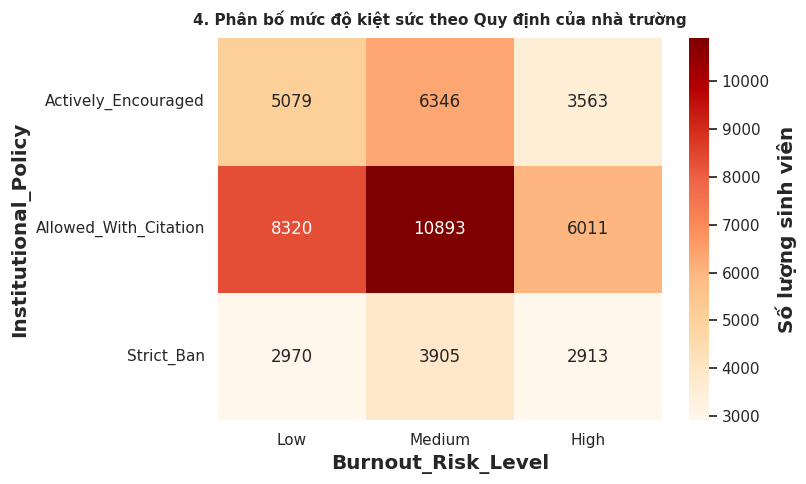

In [79]:
print("============ CROSSTAB 4: QUY ĐỊNH TRƯỜNG & MỨC ĐỘ KIỆT SỨC ============")
count_policy_by_burnout = pd.crosstab(
    index=df['Institutional_Policy'],
    columns=df['Burnout_Risk_Level']
)[['Low', 'Medium', 'High']]

print("\n Bảng tần suất số lượng sinh viên:")
print(count_policy_by_burnout)

plt.figure(figsize=(8, 5))
sns.heatmap(count_policy_by_burnout, annot=True, fmt='d', cmap='OrRd', cbar_kws={'label': 'Số lượng sinh viên'})

plt.yticks(rotation=0)
plt.xticks(rotation=0)

plt.title('4. Phân bố mức độ kiệt sức theo Quy định của nhà trường', fontsize=11, fontweight='bold')
plt.ylabel('Institutional_Policy')
plt.xlabel('Burnout_Risk_Level')
plt.tight_layout()
plt.show()

**💡 Insight:** Sinh viên ở nơi Strict_Ban có tỷ lệ Burnout High cao nhất (29.8%), trong khi hai policy khác (Encouraged & Allowed) có tỷ lệ gần nhau (23.8%).
Điều này gợi ý: Cấm cứng AI có thể gây stress/burnout cao hơn (có thể sinh viên vẫn dùng lén, hoặc cảm thấy bị hạn chế).

============ CROSSTAB 5: MỤC ĐÍCH SỬ DỤNG AI & MỨC ĐỘ KIỆT SỨC ============

📊 Bảng tần suất số lượng sinh viên:
Burnout_Risk_Level          Low  Medium  High
Primary_Use_Case                             
Copywriting/Drafting       4076    5174  2761
Debugging/Troubleshooting  3822    5119  3354
Direct_Answer_Generation   2021    2632  1687
Ideation                   3542    4568  2611
Summarizing_Reading        2908    3651  2074


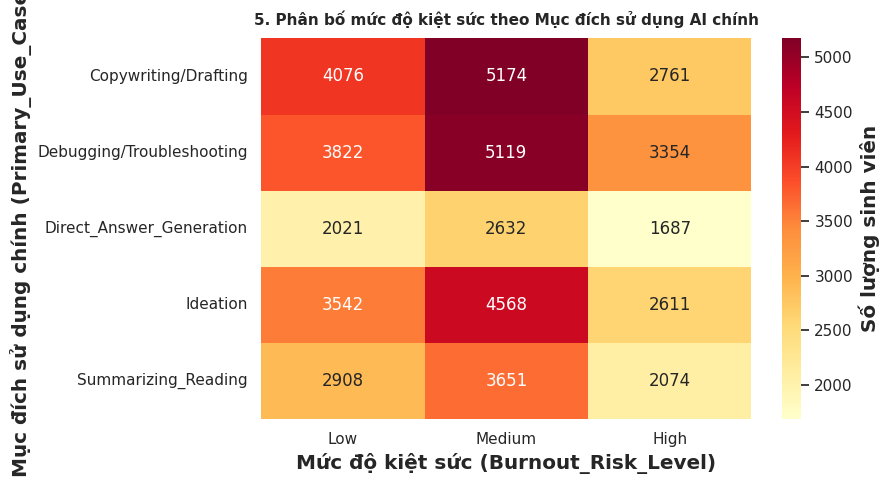

In [82]:
print("============ CROSSTAB 5: MỤC ĐÍCH SỬ DỤNG AI & MỨC ĐỘ KIỆT SỨC ============")
count_usecase_by_burnout = pd.crosstab(
    index=df['Primary_Use_Case'],
    columns=df['Burnout_Risk_Level']
)[['Low', 'Medium', 'High']]

print("\n📊 Bảng tần suất số lượng sinh viên:")
print(count_usecase_by_burnout)

plt.figure(figsize=(9, 5))
sns.heatmap(count_usecase_by_burnout, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Số lượng sinh viên'})
plt.yticks(rotation=0)
plt.xticks(rotation=0)

plt.title('5. Phân bố mức độ kiệt sức theo Mục đích sử dụng AI chính', fontsize=11, fontweight='bold')
plt.ylabel('Mục đích sử dụng chính (Primary_Use_Case)')
plt.xlabel('Mức độ kiệt sức (Burnout_Risk_Level)')
plt.tight_layout()
plt.show()

**💡 Insight:** Số liệu thực tế phản ánh xu hướng sử dụng công cụ GenAI của sinh viên tập trung mạnh vào các tác vụ phức tạp như sửa lỗi/lập trình (*Debugging*) và viết lách (*Copywriting*). Việc các tác vụ này chiếm tỷ trọng kiệt sức cao vượt trội cho thấy tính chất công việc đòi hỏi tư duy kéo dài, kết hợp với việc phụ thuộc vào AI có khả năng đẩy sinh viên vào trạng thái quá tải tâm lý cao hơn đáng kể so với việc chỉ dùng AI để ăn sẵn câu trả lời nhanh (*Direct_Answer_Generation*). Đây là đặc trưng phân hóa bối cảnh cực kỳ chính xác để mô hình học máy gán trọng số rủi ro.



## Correlation Analysis (Minh Hoàng)

Yêu cầu:
- Kiểm tra dữ liệu:
  - Kiểm tra phân phối của biến mục tiêu. Nếu bị lệch quá nhiều (Skewed), cần đề xuất các phương pháp biến đổi (như Log Transformation) để chuẩn hóa dữ liệu.

- Phân tích Đa biến :
  - Dùng điểm tương hỗ MI (Mutual Information) để lọc ra các biến quan trọng với biến mục tiêu. Từ đó, xem xét các mối quan hệ xoay quanh những biến có điểm MI cao.
  - Biến mục tiêu và các biến định lượng: Vẽ biểu đồ Boxplot hoặc Violin Plot của biến định lượng theo từng nhóm của Target (nếu Target là định tính), hoặc vẽ Scatter Plot (nếu cả hai là định lượng) để xem biến định lượng nào tác động mạnh đến Target.

  - Biến mục tiêu và biến dịnh tính: Vẽ biểu đồ cột chồng hoặc biểu đồ tỉ lệ để xem tỷ lệ phân bố của Target thay đổi như thế nào trên từng danh mục.

# Step 2: Data Preprocessing

Yêu cầu:
- clean: xử lý dữ liệu bị khuyết, trùng lặp, sửa lỗi định dạng và kiểu dữ liệu
- encode: mã hóa các biến phân loại
- impute: điền vào các giá trị NaN

In [ ]:
def load_data():
    # Read data
    data_dir = "/content/ai_student_impact_dataset.csv"
    df = pd.read_csv(data_dir, index_col="Student_Id")
    # Preprocessing
    df = clean(df)
    df = encode(df)
    df = impute(df)

    # Reform splits
    df = df.loc[df.index, :]
    return df

### Clean data

In [ ]:
def clean(df):
  ''' Hàm làm sạch dữ liệu'''
  return df


### Impute data

In [ ]:
def impute(df):
  ''' Hàm thêm các giá trị khuyết'''
  return df

### Encode data

In [ ]:
def encode(df):
  ''' Hàm mã hóa dữ liệu'''
  return df


# Step 3: Feature Engineering

# Step 4: Modelling